In [ ]:
# Install the Kaggle library to facilitate dataset downloading
!pip install kaggle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, json, shutil, sys, math, time, random, zipfile, pathlib, warnings
warnings.filterwarnings("ignore")

from google.colab import files

# Prompt user to upload the kaggle.json file for API authentication
print("Upload your kaggle.json (from https://www.kaggle.com/settings).")
uploaded = files.upload()
# Verification step to ensure the correct file was uploaded
assert "kaggle.json" in uploaded, "Please upload kaggle.json"

# Create the standard Kaggle configuration directory if it doesn't exist
os.makedirs("/root/.kaggle", exist_ok=True)

# Move the uploaded JSON file to the configuration directory
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

# Set file permissions to read/write for the owner only (security requirement for Kaggle API)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

# Verify installation by printing the version
!kaggle --version

Upload your kaggle.json (from https://www.kaggle.com/settings).


Saving kaggle.json to kaggle.json
Kaggle API 1.7.4.5


In [ ]:
# Download the specified dataset (alphadeadpool/isic-melonma) using the Kaggle API
!kaggle datasets download alphadeadpool/isic-melonma

Dataset URL: https://www.kaggle.com/datasets/alphadeadpool/isic-melonma
License(s): unknown
 99% 2.06G/2.08G [00:20<00:00, 37.1MB/s]
100% 2.08G/2.08G [00:20<00:00, 108MB/s] 


In [ ]:
# Unzip the downloaded dataset into the '/content/isic-melonma' directory
# -o overwrites existing files without prompting
!unzip -o /content/isic-melonma.zip -d /content/isic-melonma

In [ ]:
import os
import shutil
import zipfile
import subprocess
import pandas as pd
import numpy as np
import glob
from sklearn.model_selection import train_test_split

# ==========================================
# PART 1: KAGGLE SETUP & DOWNLOAD
# ==========================================
def setup_and_download():
    print("--- [1/4] Setting up Environment ---")
    subprocess.run(["pip", "install", "-q", "kaggle"], check=True)

    # Configure Kaggle directory
    kaggle_dir = os.path.expanduser("~/.kaggle")
    if not os.path.exists(kaggle_dir):
        os.makedirs(kaggle_dir)

     # Locate kaggle.json (either in Colab root or uploaded)
    local_key = "kaggle.json"
    if not os.path.exists(local_key):
        if os.path.exists("/content/kaggle.json"):
             local_key = "/content/kaggle.json"
        else:
             raise FileNotFoundError("Please upload 'kaggle.json' to the Colab files first!")

    # Copy key to config dir and set permissions
    shutil.copy(local_key, os.path.join(kaggle_dir, "kaggle.json"))
    os.chmod(os.path.join(kaggle_dir, "kaggle.json"), 0o600)
    print("API Key configured.")

    print("\n--- [2/4] Downloading Dataset ---")
    dataset_slug = "alphadeadpool/isic-melonma"

    # Download dataset only if zip doesn't exist
    if not os.path.exists("isic-melonma.zip"):
        subprocess.run(["kaggle", "datasets", "download", "-d", dataset_slug], check=True)

    extract_to = "isic-melonma"
    # Extract only if directory doesn't exist
    if not os.path.exists(extract_to):
        print(f"Extracting to {extract_to}...")
        with zipfile.ZipFile("isic-melonma.zip", 'r') as z:
            z.extractall(extract_to)

    # Find the correct CSV file (ignoring license files)
    potential_files = glob.glob(os.path.join(extract_to, "*.csv"))
    csv_files = [f for f in potential_files if "license" not in f.lower()]

    if not csv_files:
        raise FileNotFoundError("No CSV file found!")

    # Prioritize CSVs with 'metadata' or 'melanoma' in the name
    target_csv = csv_files[0]
    for f in csv_files:
        if "metadata" in f.lower() or "melanoma" in f.lower():
            target_csv = f
            break

    return target_csv, extract_to

# ==========================================
# PART 2: LEAKAGE-PROOF SPLIT & BALANCE
# ==========================================
def apply_forensic_cleaning(csv_path, image_folder_path):
    print("\n--- [3/4] Applying Forensic Cleaning & Splitting ---")
    df = pd.read_csv(csv_path)

    #6
    # (Appears to be a stray integer from original code, kept as requested)
    print(f"Mapping images from {image_folder_path}...")

    # Map image IDs to actual file paths on disk
    id_to_path_map = {}
    valid_exts = {'.jpg', '.jpeg', '.png', '.tif', '.tiff'}
    for f in os.listdir(image_folder_path):
        name, ext = os.path.splitext(f)
        if ext.lower() in valid_exts:
            full_path = os.path.join(image_folder_path, f)
            id_to_path_map[name] = full_path

    if 'isic_id' not in df.columns:
        print("Error: 'isic_id' column not found in CSV.")
        return None, None

    #Attach paths to dataframe and drop rows where image is missing
    df['image_path'] = df['isic_id'].map(id_to_path_map)
    df = df.dropna(subset=['image_path'])


    # Filter for dermoscopic images only (standardizing input type)
    if 'image_type' in df.columns:
        df = df[df['image_type'] == 'dermoscopic'].copy()


    # Ensure thickness data exists
    thick_col = 'mel_thick_mm'
    if thick_col not in df.columns:
        pass
    df = df.dropna(subset=[thick_col])

    # Logic to assign stages based on Breslow thickness
    def get_paper_stage(thick):
        if thick < 0.76: return 'Stage I'
        elif 0.76 <= thick <= 1.5: return 'Stage II'
        elif thick > 1.5: return 'Stage III'
        return None

    df['paper_stage'] = df[thick_col].apply(get_paper_stage)


    # Remove duplicates based on lesion_id to prevent data leakage
    df_clean = df.drop_duplicates(subset=['lesion_id'], keep='first')

    print(f"Clean Unique Lesions: {len(df_clean)}")


    # Split into Train/Val while maintaining stage distribution (stratify)
    train_df, val_df = train_test_split(
        df_clean,
        test_size=0.2,
        stratify=df_clean['paper_stage'],
        random_state=123
    )

    print("\n--- [4/4] Balancing Training Set ---")

    # Undersampling/Balancing logic: limit each stage to specific count
    TARGET_COUNT = 40

    train_balanced_dfs = []
    for stage in ['Stage I', 'Stage II', 'Stage III']:
        stage_df = train_df[train_df['paper_stage'] == stage]

        if len(stage_df) == 0:
            print(f"Warning: No training data for {stage}")
            continue

        # If data is less than target, replace=True (oversample), else False (undersample)
        replace_flag = len(stage_df) < TARGET_COUNT

        sampled = stage_df.sample(n=TARGET_COUNT, replace=replace_flag, random_state=123)
        train_balanced_dfs.append(sampled)

    final_train = pd.concat(train_balanced_dfs).sample(frac=1, random_state=123)

    # Save processed CSVs
    final_train.to_csv("train_balanced.csv", index=False)
    val_df.to_csv("val_clean.csv", index=False)

    print("\nSUCCESS: Dataset Prepared (New Shuffle 123).")
    return final_train, val_df

if __name__ == "__main__":
    try:
        csv_loc, img_dir = setup_and_download()
        apply_forensic_cleaning(csv_loc, img_dir)
    except Exception as e:
        print(f"Error: {e}")

--- [1/4] Setting up Environment ---
API Key configured.

--- [2/4] Downloading Dataset ---

--- [3/4] Applying Forensic Cleaning & Splitting ---
Mapping images from isic-melonma...
Clean Unique Lesions: 93

--- [4/4] Balancing Training Set ---

SUCCESS: Dataset Prepared (New Shuffle 123).


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import pandas as pd
import numpy as np
import random
import os
import torch.nn.functional as F

# ==========================================
# 1. CONFIGURATION
# ==========================================
class Config:
    BATCH_SIZE = 32
    EPOCHS = 50
    LEARNING_RATE = 1e-4
    MARGIN = 1.0
    EMBEDDING_DIM = 128
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    TRAIN_CSV = "train_balanced.csv"
    VAL_CSV = "val_clean.csv"
    IMAGE_DIR = "isic-melonma"

# ==========================================
# 2. HELPER: DATA LOADING
# ==========================================
def load_dataframe_with_paths(csv_file):
    if not os.path.exists(csv_file):
        raise FileNotFoundError(f"CSV {csv_file} not found.")
    df = pd.read_csv(csv_file)
    if 'image_path' not in df.columns:
        print("Regenerating image paths...")
        pass
    return df

# ==========================================
# 3. TRANSFORMS
# ==========================================
def get_transforms(train=True):
    if train:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(20),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

# ==========================================
# 4. SIAMESE DATASET
# ==========================================
class SiameseDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = load_dataframe_with_paths(csv_file)
        self.transform = transform
        self.grouped = self.data.groupby('paper_stage')
        self.stages = list(self.data['paper_stage'].unique())

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        # Select first image (Anchor)
        row1 = self.data.iloc[index]
        img1 = Image.open(row1['image_path']).convert('RGB')
        label1 = row1['paper_stage']

        # Determine if we pick a Positive (same class) or Negative (diff class) pair
        should_get_same = random.random() > 0.5
        if should_get_same:
            label2 = label1
            row2 = self.grouped.get_group(label1).sample(1).iloc[0]
            target = torch.tensor([1], dtype=torch.float32) # Similarity flag
        else:
            label2 = random.choice([l for l in self.stages if l != label1])
            row2 = self.grouped.get_group(label2).sample(1).iloc[0]
            target = torch.tensor([0], dtype=torch.float32) # Dissimilarity flag

        img2 = Image.open(row2['image_path']).convert('RGB')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, target

# ==========================================
# 5. MODEL & LOSS
# ==========================================
class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        resnet = models.resnet18(pretrained=True)
        # Remove the final classification layer of ResNet
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        # Add custom fully connected layers for embedding
        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, Config.EMBEDDING_DIM)
        )

    def forward_one(self, x):
        x = self.backbone(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.fc(x)

        x = F.normalize(x, p=2, dim=1) # Normalize embeddings
        return x

    def forward(self, input1, input2):
        # Process both images through the same network (shared weights)
        return self.forward_one(input1), self.forward_one(input2)

class ContrastiveLoss(nn.Module):
  """
    Contrastive Loss function.
    Minimizes distance for same-class pairs, maximizes distance for diff-class pairs (up to a margin).
    """
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        euclidean_distance = F.pairwise_distance(output1, output2)
        loss_contrastive = torch.mean((label) * torch.pow(euclidean_distance, 2) +
                                      (1-label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        return loss_contrastive

# ==========================================
# 6. EVALUATION
# ==========================================
def evaluate_accuracy(model, device):
  """
    Evaluates model using N-Shot learning approach.
    Compares Query images (validation) against Support images (training) via embedding distance.
    """
    class StandardDataset(Dataset):
        def __init__(self, csv_file, transform):
            self.data = pd.read_csv(csv_file)
            self.transform = transform
            self.labels = {label: i for i, label in enumerate(sorted(self.data['paper_stage'].unique()))}
        def __len__(self): return len(self.data)
        def __getitem__(self, idx):
            row = self.data.iloc[idx]
            img = Image.open(row['image_path']).convert('RGB')
            if self.transform:
                img = self.transform(img)
            return img, self.labels[row['paper_stage']]

    model.eval()
    # Load Train (Support) and Val (Query) datasets purely for feature extraction
    train_ds = StandardDataset(Config.TRAIN_CSV, get_transforms(False))
    val_ds = StandardDataset(Config.VAL_CSV, get_transforms(False))
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

    # Extract embeddings for support set
    support_embs, support_lbls = [], []
    with torch.no_grad():
        for imgs, lbls in train_loader:
            support_embs.append(model.forward_one(imgs.to(device)).cpu())
            support_lbls.append(lbls)
    support_embs = torch.cat(support_embs)
    support_lbls = torch.cat(support_lbls)

    # Extract embeddings for query set
    query_embs, query_lbls = [], []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            query_embs.append(model.forward_one(imgs.to(device)).cpu())
            query_lbls.append(lbls)
    query_embs = torch.cat(query_embs)
    query_lbls = torch.cat(query_lbls)

    # Calculate distances between every query and every support embedding
    dists = torch.cdist(query_embs, support_embs)
    # Find nearest neighbor
    min_dists, min_indices = torch.min(dists, dim=1)
    preds = support_lbls[min_indices]

    acc = (preds == query_lbls).float().mean().item()
    return acc * 100

# ==========================================
# 7. TRAINING LOOp
# ==========================================
def train():
    print("--- Training with Best Model Checkpointing ---")

    train_ds = SiameseDataset(Config.TRAIN_CSV, transform=get_transforms(True))
    train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True)

    model = SiameseNetwork().to(Config.DEVICE)
    criterion = ContrastiveLoss(margin=Config.MARGIN)
    optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)


    # Learning rate scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

    best_acc = 0.0
    for epoch in range(Config.EPOCHS):
        model.train()
        total_loss = 0

        for img1, img2, target in train_loader:
            img1, img2, target = img1.to(Config.DEVICE), img2.to(Config.DEVICE), target.to(Config.DEVICE)
            optimizer.zero_grad()
            out1, out2 = model(img1, img2)
            loss = criterion(out1, out2, target.view(-1))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()


        scheduler.step()
        avg_loss = total_loss / len(train_loader)


        # Check accuracy and save if it's the best so far
        acc = evaluate_accuracy(model, Config.DEVICE)

        save_msg = ""
        if acc >= best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "siamese_melanoma_model.pth")
            save_msg = "--> SAVED BEST MODEL"

        print(f"Epoch [{epoch+1}/{Config.EPOCHS}] Loss: {avg_loss:.4f}  {save_msg}")

    print(f"\n--- Finished. Best Accuracy was: {best_acc:.2f}% ---")
    print("Model 'siamese_melanoma_model.pth' contains the weights from that best epoch.")

if __name__ == "__main__":
    train()

--- Training with Best Model Checkpointing ---
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 41.6MB/s]


Epoch [1/50] Loss: 0.2854  --> SAVED BEST MODEL
Epoch [2/50] Loss: 0.2124  --> SAVED BEST MODEL
Epoch [3/50] Loss: 0.1673  
Epoch [4/50] Loss: 0.1463  
Epoch [5/50] Loss: 0.1506  
Epoch [6/50] Loss: 0.1511  
Epoch [7/50] Loss: 0.1200  
Epoch [8/50] Loss: 0.1127  
Epoch [9/50] Loss: 0.0963  
Epoch [10/50] Loss: 0.1336  
Epoch [11/50] Loss: 0.0989  
Epoch [12/50] Loss: 0.1095  
Epoch [13/50] Loss: 0.0801  
Epoch [14/50] Loss: 0.0657  
Epoch [15/50] Loss: 0.0681  
Epoch [16/50] Loss: 0.0601  
Epoch [17/50] Loss: 0.0548  
Epoch [18/50] Loss: 0.0522  
Epoch [19/50] Loss: 0.0544  
Epoch [20/50] Loss: 0.0352  
Epoch [21/50] Loss: 0.0369  
Epoch [22/50] Loss: 0.0297  
Epoch [23/50] Loss: 0.0219  
Epoch [24/50] Loss: 0.0256  
Epoch [25/50] Loss: 0.0192  
Epoch [26/50] Loss: 0.0181  
Epoch [27/50] Loss: 0.0186  
Epoch [28/50] Loss: 0.0210  
Epoch [29/50] Loss: 0.0190  
Epoch [30/50] Loss: 0.0284  
Epoch [31/50] Loss: 0.0192  
Epoch [32/50] Loss: 0.0140  
Epoch [33/50] Loss: 0.0143  
Epoch [34/50

# **Evalution loop**

--- Starting Detailed Evaluation ---
Loading datasets...
Classes: ['Stage I', 'Stage II', 'Stage III']
Loading model from siamese_melanoma_model.pth...
Extracting Support Set (Train) Features...
Extracting Query Set (Val) Features & Predicting...

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Stage I     0.8333    0.7143    0.7692        14
    Stage II     0.5000    0.5000    0.5000         4
   Stage III     0.3333    1.0000    0.5000         1

    accuracy                         0.6842        19
   macro avg     0.5556    0.7381    0.5897        19
weighted avg     0.7368    0.6842    0.6984        19



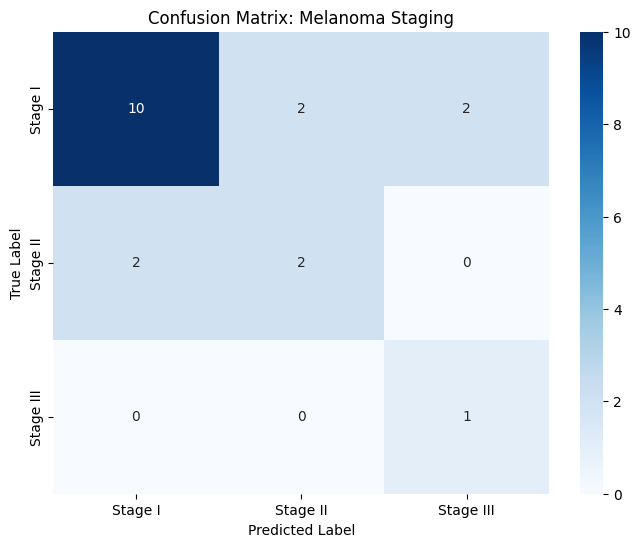

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 1. CONFIGURATION (Must match Training)
# ==========================================
class Config:
    BATCH_SIZE = 32
    EMBEDDING_DIM = 128
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Paths
    TRAIN_CSV = "train_balanced.csv"
    VAL_CSV = "val_clean.csv"
    MODEL_PATH = "siamese_melanoma_model.pth"

# ==========================================
# 2. MODEL DEFINITION (Must be identical to Training)
# ==========================================
class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        resnet = models.resnet18(pretrained=False) # Pretrained not strictly needed for loading weights later
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, Config.EMBEDDING_DIM)
        )

    def forward_one(self, x):
        x = self.backbone(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# ==========================================
# 3. HELPER FUNCTIONS
# ==========================================
def get_transforms():
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

def load_dataframe_with_paths(csv_file):
    if not os.path.exists(csv_file):
        raise FileNotFoundError(f"Missing {csv_file}")
    df = pd.read_csv(csv_file)
    if 'image_path' not in df.columns:
        raise ValueError(f"CSV {csv_file} missing 'image_path' column. Re-run preprocessing.")
    return df

class EvalDataset(Dataset):
    def __init__(self, csv_file, transform):
        self.data = load_dataframe_with_paths(csv_file)
        self.transform = transform
        self.classes = sorted(self.data['paper_stage'].unique())
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        label_name = row['paper_stage']
        label_idx = self.class_to_idx[label_name]

        if self.transform:
            img = self.transform(img)

        return img, label_idx

# ==========================================
# 4. MAIN EVALUATION LOGIC
# ==========================================
def generate_evaluation_report():
    print("--- Starting Detailed Evaluation ---")

    print("Loading datasets...")
    transform = get_transforms()
    train_ds = EvalDataset(Config.TRAIN_CSV, transform)
    val_ds = EvalDataset(Config.VAL_CSV, transform)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

    print(f"Classes: {train_ds.classes}")

    print(f"Loading model from {Config.MODEL_PATH}...")
    model = SiameseNetwork().to(Config.DEVICE)
    if os.path.exists(Config.MODEL_PATH):
        model.load_state_dict(torch.load(Config.MODEL_PATH, map_location=Config.DEVICE))
    else:
        raise FileNotFoundError("Model file not found. Train the model first!")

    model.eval()

    print("Extracting Support Set (Train) Features...")
    support_embs = []
    support_lbls = []
    with torch.no_grad():
        for imgs, lbls in train_loader:
            imgs = imgs.to(Config.DEVICE)
            embs = model.forward_one(imgs)
            support_embs.append(embs.cpu())
            support_lbls.append(lbls)
    support_embs = torch.cat(support_embs)
    support_lbls = torch.cat(support_lbls)

    print("Extracting Query Set (Val) Features & Predicting...")
    query_lbls_true = []
    query_lbls_pred = []

    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs = imgs.to(Config.DEVICE)

            # Get embedding for current batch of validation images
            q_emb = model.forward_one(imgs).cpu()


            # Calculate distance to all support embeddings
            dists = torch.cdist(q_emb, support_embs)

            # Find the closest support image
            min_dist, min_indices = torch.min(dists, dim=1)

            # Assign label of the closest support image to the query image
            preds = support_lbls[min_indices]

            query_lbls_true.extend(lbls.tolist())
            query_lbls_pred.extend(preds.tolist())

    # ==========================================
    # 5. GENERATE RESULTS
    # ==========================================

    print("\n" + "="*30)
    print("CLASSIFICATION REPORT")
    print("="*30)
    report = classification_report(
        query_lbls_true,
        query_lbls_pred,
        target_names=train_ds.classes,
        digits=4
    )
    print(report)

    cm = confusion_matrix(query_lbls_true, query_lbls_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=train_ds.classes,
                yticklabels=train_ds.classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: Melanoma Staging')
    plt.show()

if __name__ == "__main__":
    generate_evaluation_report()